In [75]:
# --- Import Required Libraries ---
import pandas as pd   # Used for loading data and performing data analysis
import numpy as np    # Helpful for numerical operations (optional but common)

# --- Load Dataset ---
df = pd.read_csv("Fragrance Dataset - COM7022 - [4037].csv")

In [76]:
# --- Display Preview of Data ---
print("\n--- DataFrame Head ---")
print(df.head())


--- DataFrame Head ---
            brand                                              title  \
0            Dior  Christian Dior Sauvage Men's EDP 3.4 oz Fragra...   
1         AS SHOW  A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...   
2       Unbranded                   HOGO BOSS cologne For Men 3.4 oz   
3  Giorgio Armani  Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...   
4         Lattafa  Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...   

              type   price priceWithCurrency  available  \
0    Eau de Parfum   84.99      US $84.99/ea       10.0   
1    Eau de Parfum  109.99        US $109.99        8.0   
2  Eau de Toilette  100.00        US $100.00       10.0   
3  Eau de Toilette     NaN      US $44.99/ea        2.0   
4       Fragrances   16.91         US $16.91        NaN   

                           availableText   sold                lastUpdated  \
0      More than 10 available / 116 sold  116.0  May 24, 2024 10:03:04 PDT   
1                  8 available /

In [77]:
# --- Basic Dataset Information ---
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData types of each column:\n", df.dtypes)


Number of rows: 1000
Number of columns: 10

Data types of each column:
 brand                 object
title                 object
type                  object
price                float64
priceWithCurrency     object
available            float64
availableText         object
sold                 float64
lastUpdated           object
itemLocation          object
dtype: object


In [78]:
# --- Identify Numeric vs Categorical Columns ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)



Numeric Columns: ['price', 'available', 'sold']
Categorical Columns: ['brand', 'title', 'type', 'priceWithCurrency', 'availableText', 'lastUpdated', 'itemLocation']


In [79]:
# --- Identify Numeric vs Categorical Columns ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [81]:
print("\n--- DataFrame Info ---")
df.info()



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              996 non-null    float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [83]:
# --- Checking for Missing Values ---
print("\nMissing values per column:\n", df.isnull().sum())



Missing values per column:
 brand                  1
title                  0
type                   3
price                  4
priceWithCurrency      0
available            111
availableText          3
sold                   6
lastUpdated           53
itemLocation           0
dtype: int64


In [96]:
# --- Checking for Duplicate Rows ---
print("\nNumber of duplicate rows:", df.duplicated().sum())



Number of duplicate rows: 0


In [97]:
# --- Detect simple inconsistencies (optional small check) ---
if 'price' in df.columns:
    print("\nNumber of missing price values:", df['price'].isna().sum())



Number of missing price values: 4


In [86]:

print("\n--- DataFrame Describe ---")
print(df.describe(include='all'))



--- DataFrame Describe ---
                 brand                                              title  \
count              999                                               1000   
unique             246                                                966   
top     Giorgio Armani  Hawas for him Eau De Parfum By Rasasi 100ml 3....   
freq                60                                                  4   
mean               NaN                                                NaN   
std                NaN                                                NaN   
min                NaN                                                NaN   
25%                NaN                                                NaN   
50%                NaN                                                NaN   
75%                NaN                                                NaN   
max                NaN                                                NaN   

                   type       price priceWithCu

In [90]:

# DATA PREPROCESSING

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Fragrance Dataset - COM7022 - [4037].csv")

print("Before preprocessing:")
print(df.head())
print(df.isnull().sum())


# 1. Handling Missing Values (SIMPLE: DROP THEM)
# Justification:
# Dropping missing values is the simplest method and avoids incorrect guessing.
df = df.dropna()
print("\nAfter dropping missing values:")
print(df.isnull().sum())
print("New shape:", df.shape)


# 2. Handling Outliers (SIMPLE: CLIP EXTREMES)

# Clip extreme values to reduce influence of outliers.
if 'price' in df.columns:
    df['price'] = df['price'].clip(df['price'].quantile(0.01),
                                   df['price'].quantile(0.99))

if 'sold' in df.columns:
    df['sold'] = df['sold'].clip(df['sold'].quantile(0.01),
                                 df['sold'].quantile(0.99))


# 3. Scaling & Normalisation (StandardScaler)

# Justification:
# StandardScaler makes numeric features comparable.
scaler = StandardScaler()

simple_num_cols = []
if 'price' in df.columns: simple_num_cols.append('price')
if 'available' in df.columns: simple_num_cols.append('available')
if 'sold' in df.columns: simple_num_cols.append('sold')

df[simple_num_cols] = scaler.fit_transform(df[simple_num_cols])


# 4. Encode Categorical Columns (Simple Category Codes)

# Justification: category codes are the simplest encoding.
if 'brand' in df.columns:
    df['brand'] = df['brand'].astype('category').cat.codes

if 'type' in df.columns:
    df['type'] = df['type'].astype('category').cat.codes

if 'itemLocation' in df.columns:
    df['itemLocation'] = df['itemLocation'].astype('category').cat.codes


# 5. Remove Irrelevant Columns

if 'title' in df.columns:
    df = df.drop(columns=['title'])

if 'availableText' in df.columns:
    df = df.drop(columns=['availableText'])


# FINAL OUTPUT (Before/After Comparison)

print("\nAfter preprocessing:")
print(df.head())
print("Final shape:", df.shape)

df.to_csv("Fragrance_cleaned_simple.csv", index=False)
print("\nSaved as 'Fragrance_cleaned_simple.csv'")


Before preprocessing:
            brand                                              title  \
0            Dior  Christian Dior Sauvage Men's EDP 3.4 oz Fragra...   
1         AS SHOW  A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...   
2       Unbranded                   HOGO BOSS cologne For Men 3.4 oz   
3  Giorgio Armani  Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...   
4         Lattafa  Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...   

              type   price priceWithCurrency  available  \
0    Eau de Parfum   84.99      US $84.99/ea       10.0   
1    Eau de Parfum  109.99        US $109.99        8.0   
2  Eau de Toilette  100.00        US $100.00       10.0   
3  Eau de Toilette     NaN      US $44.99/ea        2.0   
4       Fragrances   16.91         US $16.91        NaN   

                           availableText   sold                lastUpdated  \
0      More than 10 available / 116 sold  116.0  May 24, 2024 10:03:04 PDT   
1                  8 available / 4

Data shape after selecting features & dropping missing rows: (881, 6)
Features used for clustering (columns): ['price', 'available', 'sold', 'brand', 'type', 'itemLocation']

=== A) K-MEANS CLUSTERING ===


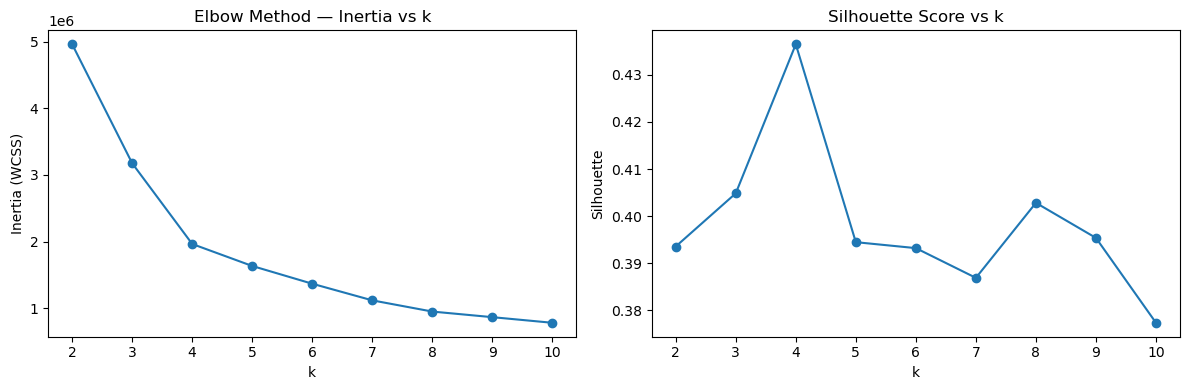

Chosen k = 4 (highest silhouette = 0.4365)


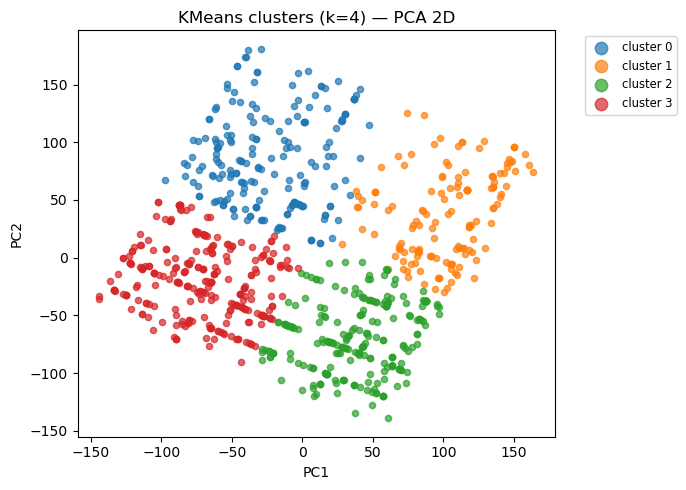


KMeans cluster sizes:
{0: 196, 1: 152, 2: 248, 3: 285}

KMeans numeric feature means per cluster:
                 price  available     sold
kmeans_cluster                            
0               48.815      8.179  248.704
1               47.550      8.388   94.507
2               40.354     29.956  771.605
3               44.420     26.154  528.877

KMeans categorical feature modes per cluster:
                         brand             type                   itemLocation
kmeans_cluster                                                                
0               Giorgio Armani  Eau de Toilette  Miami, Florida, United States
1                    Unbranded  Eau de Toilette  Miami, Florida, United States
2                 Paco Rabanne  Eau de Toilette   Dallas, Texas, United States
3               Giorgio Armani  Eau de Toilette   Dallas, Texas, United States

=== B) DBSCAN ===
DBSCAN rule-of-thumb min_samples = 12


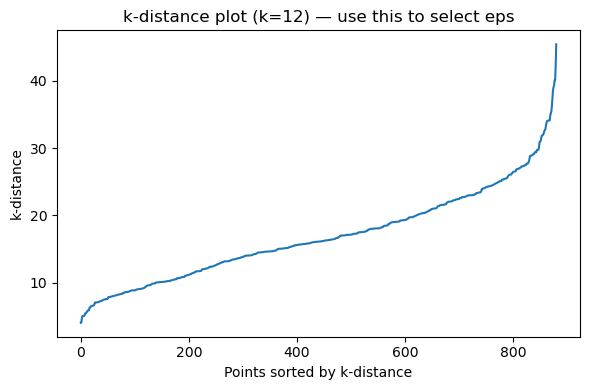

Chosen eps = 25.9523 (the 90th percentile of k-distances)


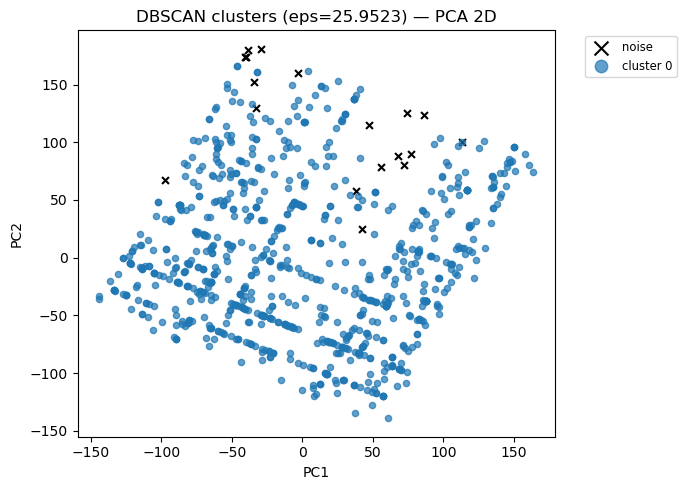


DBSCAN cluster counts (label: count): {-1: 18, 0: 863}
Number of noise points (label -1): 18

DBSCAN numeric means per cluster (excluding noise):
                 price  available     sold
dbscan_cluster                            
0               44.621     20.341  446.423

DBSCAN categorical modes per cluster (excluding noise):
                         brand             type                  itemLocation
dbscan_cluster                                                               
0               Giorgio Armani  Eau de Toilette  Dallas, Texas, United States


In [91]:

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# coping dataframe into variable CSV_PATH to avoid altering the orignal dataset for reuse

CSV_PATH = "Fragrance Dataset - COM7022 - [4037].csv"
# Features chosen because they reflect product attributes and market signals
FEATURES = ["price", "available", "sold", "brand", "type", "itemLocation"]

K_MIN, K_MAX = 2, 10                 # k range to test for KMeans
RANDOM_STATE = 42
DBSCAN_PERCENTILE = 90               # eps = 90th percentile of k-distances (simple heuristic)
DBSCAN_MIN_SAMPLES_FACTOR = 2        # min_samples = factor * n_features (rule-of-thumb)

# Helper functions

def safe_mode(series):
    """Return first mode or NaN if no mode."""
    m = series.mode()
    return m.iat[0] if not m.empty else np.nan

# -----------------------------
# 1) Load and preprocess
# -----------------------------
df = pd.read_csv(CSV_PATH)

# Keep only features that actually exist in the file
used_features = [c for c in FEATURES if c in df.columns]
if not used_features:
    raise SystemExit("No expected feature columns found in CSV. Check column names.")

# Work on a copy and drop rows with missing values in the selected features (simple choice)
data_orig = df[used_features].copy().dropna().reset_index(drop=True)
print("Data shape after selecting features & dropping missing rows:", data_orig.shape)

# Record original dtypes for safe summaries later
categorical_cols = data_orig.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = data_orig.select_dtypes(include=[np.number]).columns.tolist()

# Prepare data for clustering:
# - encode categorical columns to integer codes (simple, reproducible)
X = data_orig.copy()
for c in categorical_cols:
    X[c] = X[c].astype('category').cat.codes

# - scale numeric columns so no single feature dominates distances
scaler = StandardScaler()
if numeric_cols:
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_array = X.values
print("Features used for clustering (columns):", X.columns.tolist())

# Prepare PCA for 2D visualisation later
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca.fit_transform(X_array)


# A) K-MEANS CLUSTERING

print("\n=== A) K-MEANS CLUSTERING ===")
ks = list(range(K_MIN, K_MAX + 1))
inertias = []
silhouettes = []

# Compute inertia (WCSS) and silhouette for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_array)
    inertias.append(km.inertia_)
    try:
        silhouettes.append(silhouette_score(X_array, labels))
    except Exception:
        silhouettes.append(np.nan)

# Plot Elbow and Silhouette side-by-side (visual)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o')
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_xticks(ks)

axes[1].plot(ks, silhouettes, marker='o')
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(ks)

plt.tight_layout()
plt.show()

# Choose k: highest silhouette (practical and easy to justify in an assignment)
best_k_index = int(np.nanargmax(silhouettes))
best_k = ks[best_k_index]
best_silhouette = silhouettes[best_k_index]
print(f"Chosen k = {best_k} (highest silhouette = {best_silhouette:.4f})")

# Fit final KMeans and get labels
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
k_labels = kmeans.fit_predict(X_array)

# Show PCA scatter colored by KMeans clusters
plt.figure(figsize=(7,5))
for lbl in np.unique(k_labels):
    mask = k_labels == lbl
    plt.scatter(X_pca2[mask,0], X_pca2[mask,1], s=20, label=f"cluster {lbl}", alpha=0.7)
plt.title(f"KMeans clusters (k={best_k}) — PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize='small', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout(); plt.show()

# Print simple summaries (safe: numeric means only; categorical -> mode)
result_k = data_orig.copy()
result_k['kmeans_cluster'] = k_labels

print("\nKMeans cluster sizes:")
print(result_k['kmeans_cluster'].value_counts().sort_index().to_dict())

if numeric_cols:
    print("\nKMeans numeric feature means per cluster:")
    print(result_k.groupby('kmeans_cluster')[numeric_cols].mean().round(3))

if categorical_cols:
    print("\nKMeans categorical feature modes per cluster:")
    cat_modes_k = result_k.groupby('kmeans_cluster')[categorical_cols].agg(lambda s: safe_mode(s))
    print(cat_modes_k)

# B) DBSCAN

print("\n=== B) DBSCAN ===")
n_features = X_array.shape[1]
min_samples = max(3, DBSCAN_MIN_SAMPLES_FACTOR * n_features)  # rule-of-thumb: 2 * n_features typical
print(f"DBSCAN rule-of-thumb min_samples = {min_samples}")

# Compute k-distance (distance to the min_samples-th neighbor) and plot to inspect eps
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_array)
distances, _ = nn.kneighbors(X_array)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_distances)
plt.title(f"k-distance plot (k={min_samples}) — use this to select eps")
plt.xlabel("Points sorted by k-distance")
plt.ylabel("k-distance")
plt.tight_layout(); plt.show()

# Simple automatic eps: high percentile (90th) of the k-distance values (easy heuristic)
eps = float(np.percentile(k_distances, DBSCAN_PERCENTILE))
print(f"Chosen eps = {eps:.4f} (the {DBSCAN_PERCENTILE}th percentile of k-distances)")

# Fit DBSCAN
db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
db_labels = db.fit_predict(X_array)  # -1 indicates noise

# Visualize DBSCAN clusters on PCA 2D (noise marked)
plt.figure(figsize=(7,5))
unique_db = np.unique(db_labels)
for lbl in unique_db:
    mask = db_labels == lbl
    if lbl == -1:
        plt.scatter(X_pca2[mask,0], X_pca2[mask,1], c='k', marker='x', s=25, label='noise')
    else:
        plt.scatter(X_pca2[mask,0], X_pca2[mask,1], s=20, label=f'cluster {lbl}', alpha=0.7)
plt.title(f"DBSCAN clusters (eps={eps:.4f}) — PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize='small', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout(); plt.show()

# DBSCAN cluster summary
result_db = data_orig.copy()
result_db['dbscan_cluster'] = db_labels

unique, counts = np.unique(db_labels, return_counts=True)
label_counts = dict(zip(unique.tolist(), counts.tolist()))
n_noise = int(label_counts.get(-1, 0))
print("\nDBSCAN cluster counts (label: count):", label_counts)
print("Number of noise points (label -1):", n_noise)

# Numeric means per DBSCAN cluster (exclude noise)
if numeric_cols:
    print("\nDBSCAN numeric means per cluster (excluding noise):")
    print(result_db[result_db['dbscan_cluster'] != -1].groupby('dbscan_cluster')[numeric_cols].mean().round(3))

# Categorical modes per DBSCAN cluster (exclude noise)
if categorical_cols:
    print("\nDBSCAN categorical modes per cluster (excluding noise):")
    cat_modes_db = result_db[result_db['dbscan_cluster'] != -1].groupby('dbscan_cluster')[categorical_cols].agg(lambda s: safe_mode(s))
    print(cat_modes_db)




Using features: ['price', 'available', 'sold', 'brand', 'type', 'itemLocation']
Data shape after dropna: (881, 6)
Chosen KMeans k=2 (best silhouette ≈ 0.575) — using these labels for coloring visualisations
PCA 2 components explained variance ratio: PC1=0.240, PC2=0.197 (total 0.437)


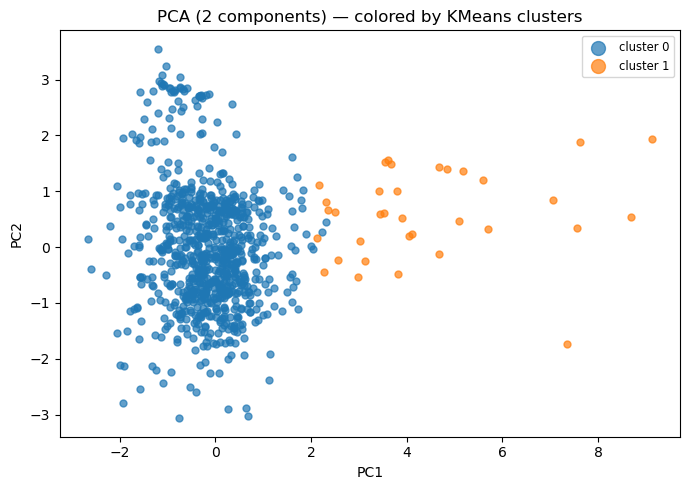

PCA 3 components explained variance ratio: [0.24  0.197 0.155], total explained 0.592


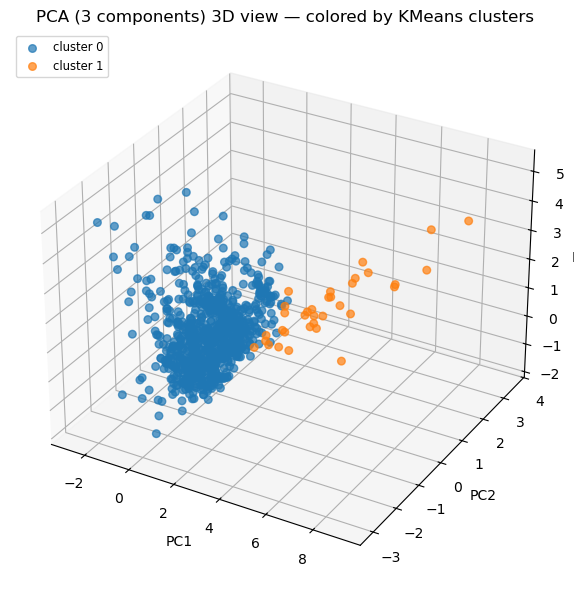

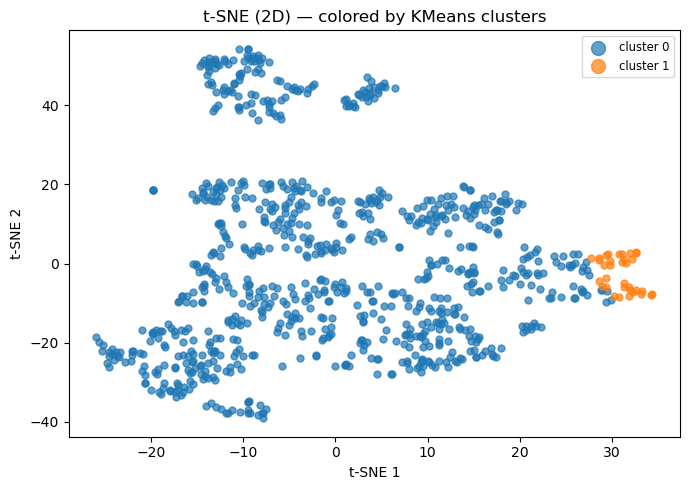

In [92]:

from sklearn.manifold import TSNE
#copying again dataframe to new variable CSV to avoid altering the orignal dataframe
CSV = "Fragrance Dataset - COM7022 - [4037].csv"
# Features that represent product attributes & market signals
FEATURES = ["price", "available", "sold", "brand", "type", "itemLocation"]

# KMeans mini-setup (only to provide labels for coloring)
K_CHOICES = range(2, 6)  # test k = 2..5 (keeps computation short)
RANDOM_STATE = 42

# t-SNE settings (default perplexity ~ 30 is OK for 100+ samples)
TSNE_PERPLEXITY = 30
TSNE_RANDOM = 42


#  Load & simple preprocess

df = pd.read_csv(CSV)

# keep only columns that exist in the CSV
used = [c for c in FEATURES if c in df.columns]
if not used:
    raise SystemExit("No expected feature columns found. Check CSV column names.")
print("Using features:", used)

# select and drop rows with missing values in these features (simple and reproducible)
data = df[used].copy().dropna().reset_index(drop=True)
print("Data shape after dropna:", data.shape)

# Preserve original (post-dropna) for summaries / interpretation
orig = data.copy()

# Encode categorical columns as integer codes for numerical methods
cat_cols = orig.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_cols:
    data[c] = data[c].astype('category').cat.codes

# Scale numeric columns so features contribute comparably
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
if num_cols:
    data[num_cols] = scaler.fit_transform(data[num_cols])

X = data.values  # numeric array ready for dimensionality reduction


#  Quick KMeans to get cluster labels for coloring
#    (we automatically choose k with a tiny silhouette loop for k=2..5)

from sklearn.metrics import silhouette_score

best_k = 2
best_sil = -1
for k in K_CHOICES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    # compute silhouette if valid
    try:
        sil = silhouette_score(X, labels)
    except:
        sil = -1
    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_labels = labels

print(f"Chosen KMeans k={best_k} (best silhouette ≈ {best_sil:.3f}) — using these labels for coloring visualisations")


# 3) PCA: 2-component view

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)
explained = pca2.explained_variance_ratio_
print(f"PCA 2 components explained variance ratio: PC1={explained[0]:.3f}, PC2={explained[1]:.3f} (total {explained.sum():.3f})")

plt.figure(figsize=(7,5))
unique_labels = np.unique(best_labels)
for lbl in unique_labels:
    mask = best_labels == lbl
    plt.scatter(X_pca2[mask,0], X_pca2[mask,1], s=25, alpha=0.7, label=f'cluster {lbl}')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA (2 components) — colored by KMeans clusters")
plt.legend(markerscale=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()


# 4) PCA: 3-component view (3D scatter)

# 3D is useful to see if clusters separate in a slightly higher linear subspace
from mpl_toolkits.mplot3d import Axes3D  # import for 3D plotting (unused variable is OK)
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X)
explained3 = pca3.explained_variance_ratio_
print(f"PCA 3 components explained variance ratio: {explained3.round(3)}, total explained {explained3.sum():.3f}")

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for lbl in unique_labels:
    mask = best_labels == lbl
    ax.scatter(X_pca3[mask,0], X_pca3[mask,1], X_pca3[mask,2], s=30, alpha=0.7, label=f'cluster {lbl}')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("PCA (3 components) 3D view — colored by KMeans clusters")
ax.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()


#  t-SNE: 2D view for nonlinear structure

# t-SNE can reveal local, nonlinear cluster shapes. It is slower but good for visualization.
perp = TSNE_PERPLEXITY
if X.shape[0] < 3 * perp:
    perp = max(5, X.shape[0] // 3)
    print(f"Adjusted t-SNE perplexity to {perp} due to small sample size")

tsne = TSNE(n_components=2, perplexity=perp, random_state=TSNE_RANDOM, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7,5))
for lbl in unique_labels:
    mask = best_labels == lbl
    plt.scatter(X_tsne[mask,0], X_tsne[mask,1], s=25, alpha=0.7, label=f'cluster {lbl}')
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE (2D) — colored by KMeans clusters")
plt.legend(markerscale=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()


In [93]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Load + simple preprocessing


df = pd.read_csv("Fragrance Dataset - COM7022 - [4037].csv")

features = ["price", "available", "sold", "brand", "type", "itemLocation"]
features = [c for c in features if c in df.columns]

data = df[features].dropna().reset_index(drop=True)

# Encode categorical features
cat_cols = data.select_dtypes(include=['object','category']).columns
for c in cat_cols:
    data[c] = data[c].astype("category").cat.codes

# Scale numeric features
num_cols = data.select_dtypes(include=['number']).columns
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

X = data.values


# KMEANS VALIDATION


kmeans = KMeans(n_clusters=4, random_state=42)
k_labels = kmeans.fit_predict(X)

# direct metrics
sil_k = silhouette_score(X, k_labels)
dbi_k = davies_bouldin_score(X, k_labels)

print("\nK-MEANS METRICS")
print("Silhouette Score:", sil_k)
print("Davies–Bouldin Index:", dbi_k)

# DBSCAN VALIDATION

# choose eps = 90th percentile of k-distances
min_samples = 2 * X.shape[1]
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nn.kneighbors(X)
eps = np.percentile(np.sort(distances[:, -1]), 90)

db = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = db.fit_predict(X)

# Try metrics (DBSCAN may have 1 cluster)
print("\nDBSCAN METRICS")
try:
    sil_db = silhouette_score(X, db_labels)
    dbi_db = davies_bouldin_score(X, db_labels)
    print("Silhouette Score:", sil_db)
    print("Davies–Bouldin Index:", dbi_db)
except:
    print("Metrics cannot be computed (DBSCAN produced only one cluster or only noise).")



K-MEANS METRICS
Silhouette Score: 0.23085726759081426
Davies–Bouldin Index: 1.4401096871799806

DBSCAN METRICS
Silhouette Score: 0.5444869520859743
Davies–Bouldin Index: 2.141673925730984
